In [ ]:
import pandas as pd

df = pd.read_csv('/content/framingham.csv')

print("--- Info ---")
print(df.info())
print("\n--- Head ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

try:
    df = pd.read_csv('/content/framingham.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'framingham.csv' not found. Please upload it to the Colab files section.")


imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

cols_to_impute_median = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
cols_to_impute_mode = ['education', 'BPMeds']

df[cols_to_impute_median] = imputer_median.fit_transform(df[cols_to_impute_median])
df[cols_to_impute_mode] = imputer_mode.fit_transform(df[cols_to_impute_mode])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")


X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\nPreprocessing Complete!")
print(f"Training set shape: {X_train_final.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")



Dataset loaded successfully!
Missing values after imputation: 0

Preprocessing Complete!
Training set shape: (3392, 15)
Testing set shape: (848, 15)


Logistic Regression

--- Logistic Regression ---
Accuracy: 0.8443
ROC-AUC:  0.7022

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848



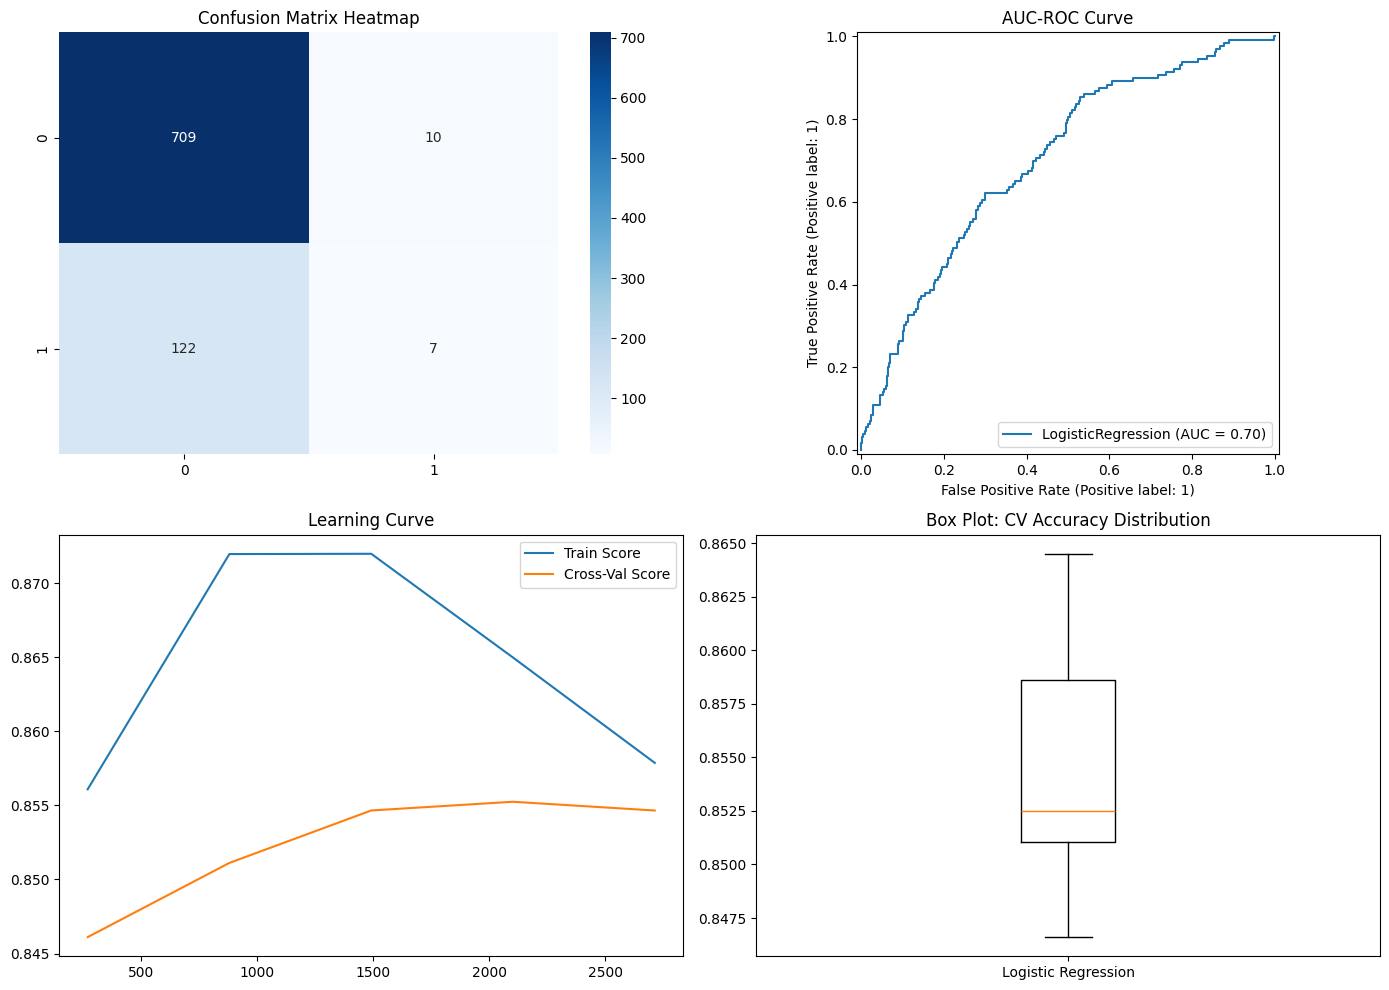

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import learning_curve, cross_val_score


model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")


RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")


train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()


axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['Logistic Regression'])

plt.tight_layout()
plt.show()

Random Forest Classifier

--- Random Forest ---
Accuracy: 0.8443
ROC-AUC:  0.6474

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.38      0.04      0.07       129

    accuracy                           0.84       848
   macro avg       0.62      0.51      0.49       848
weighted avg       0.78      0.84      0.79       848



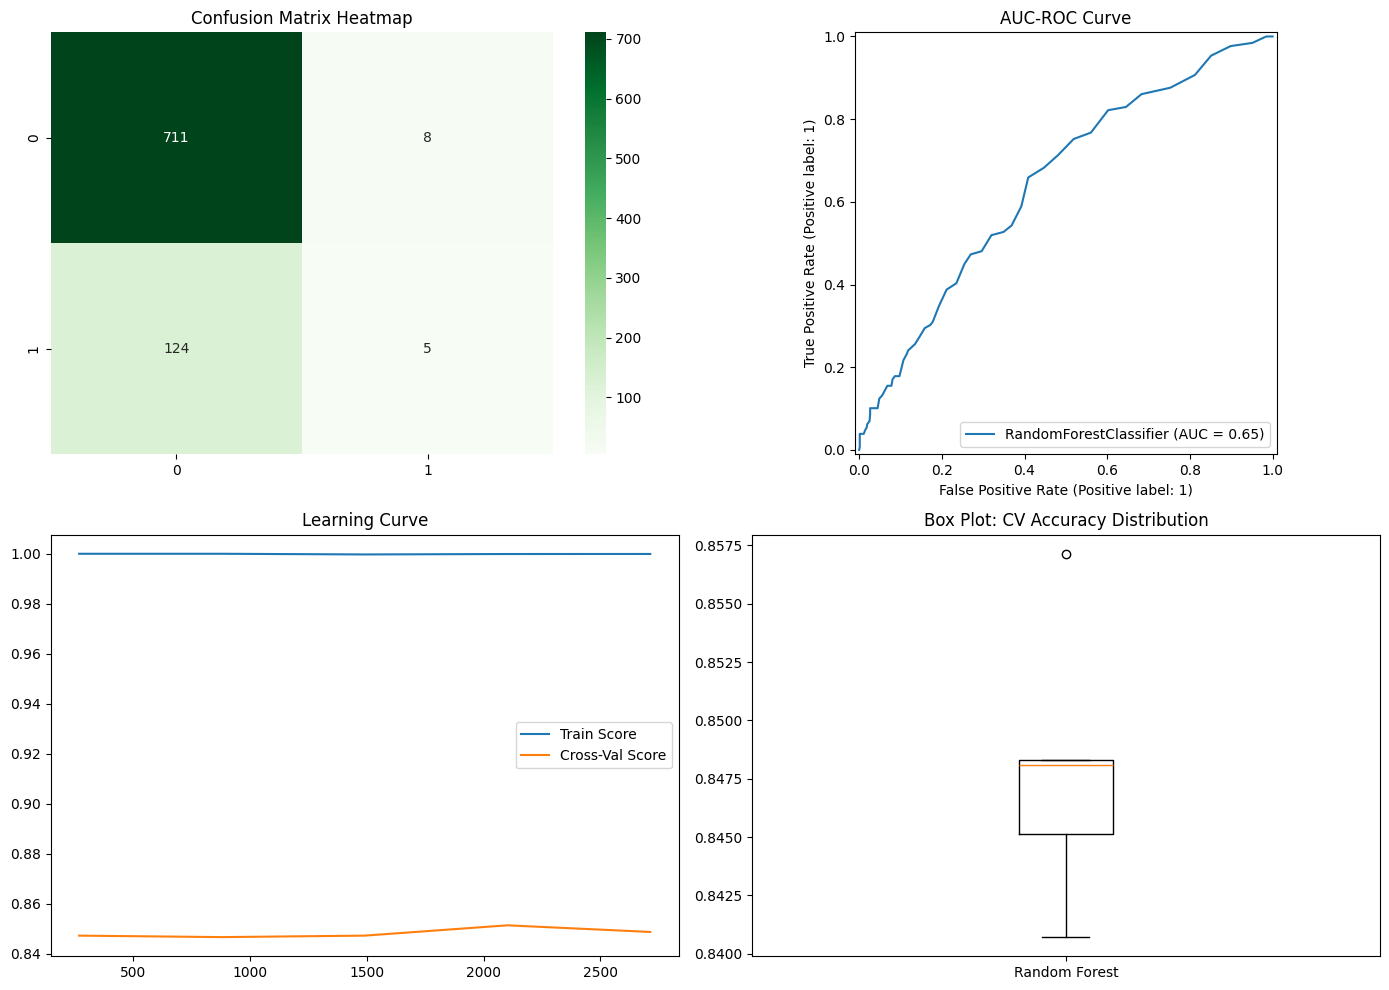

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['Random Forest'])

plt.tight_layout()
plt.show()

XGBoost Classifier

--- XGBoost ---
Accuracy: 0.8137
ROC-AUC:  0.6042

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.90       719
           1       0.23      0.09      0.13       129

    accuracy                           0.81       848
   macro avg       0.54      0.52      0.51       848
weighted avg       0.76      0.81      0.78       848



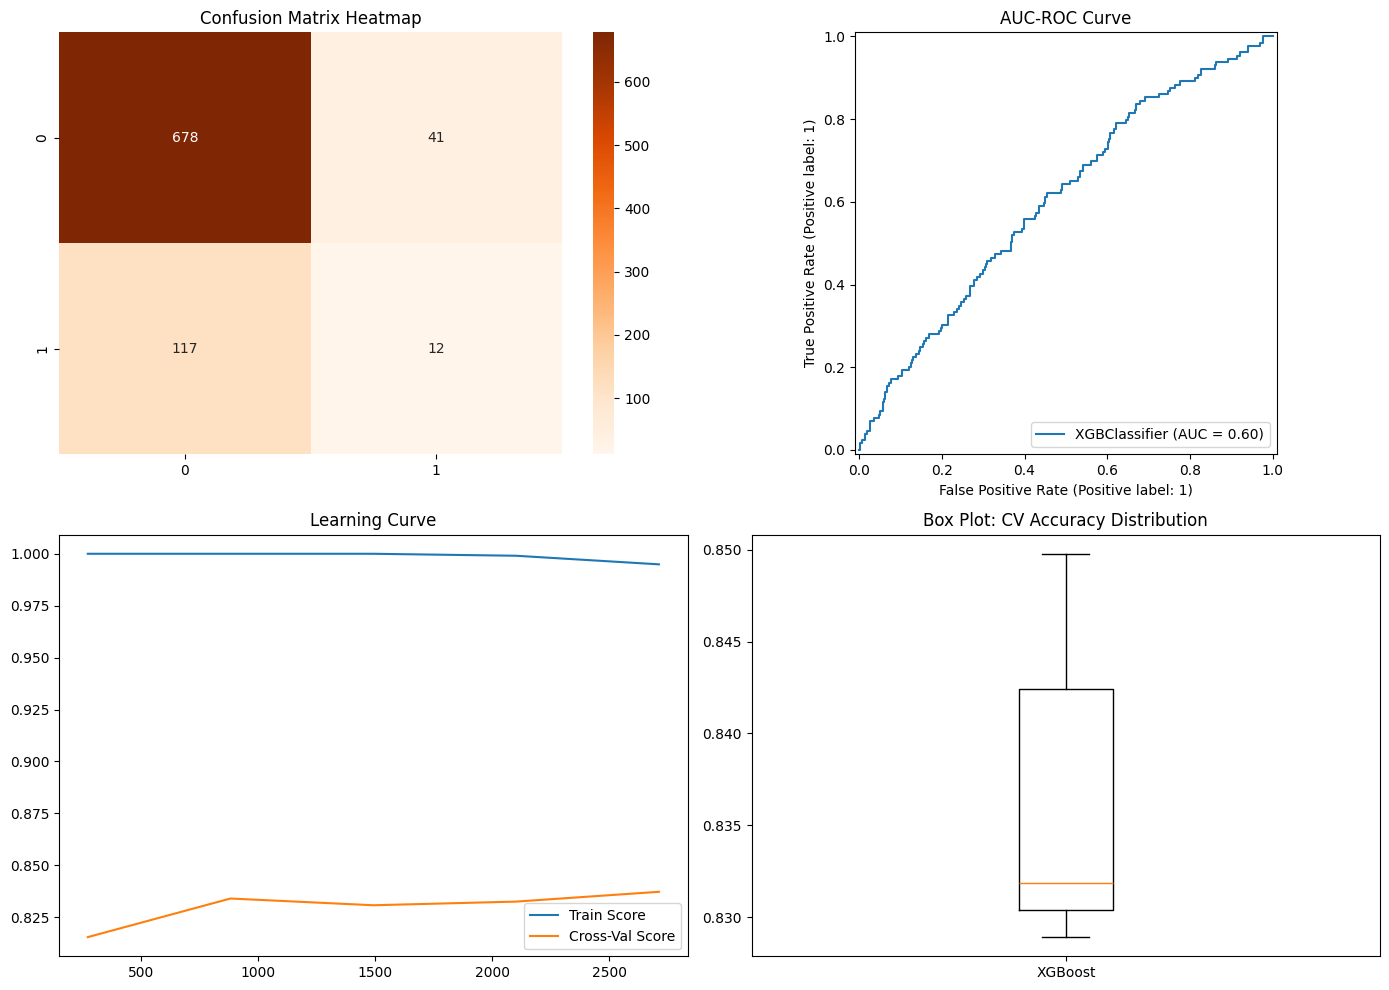

In [ ]:
from xgboost import XGBClassifier


model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['XGBoost'])

plt.tight_layout()
plt.show()


Support Vector Machine (SVM)

--- SVM ---
Accuracy: 0.8502
ROC-AUC:  0.5533

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       719
           1       0.75      0.02      0.05       129

    accuracy                           0.85       848
   macro avg       0.80      0.51      0.48       848
weighted avg       0.84      0.85      0.79       848



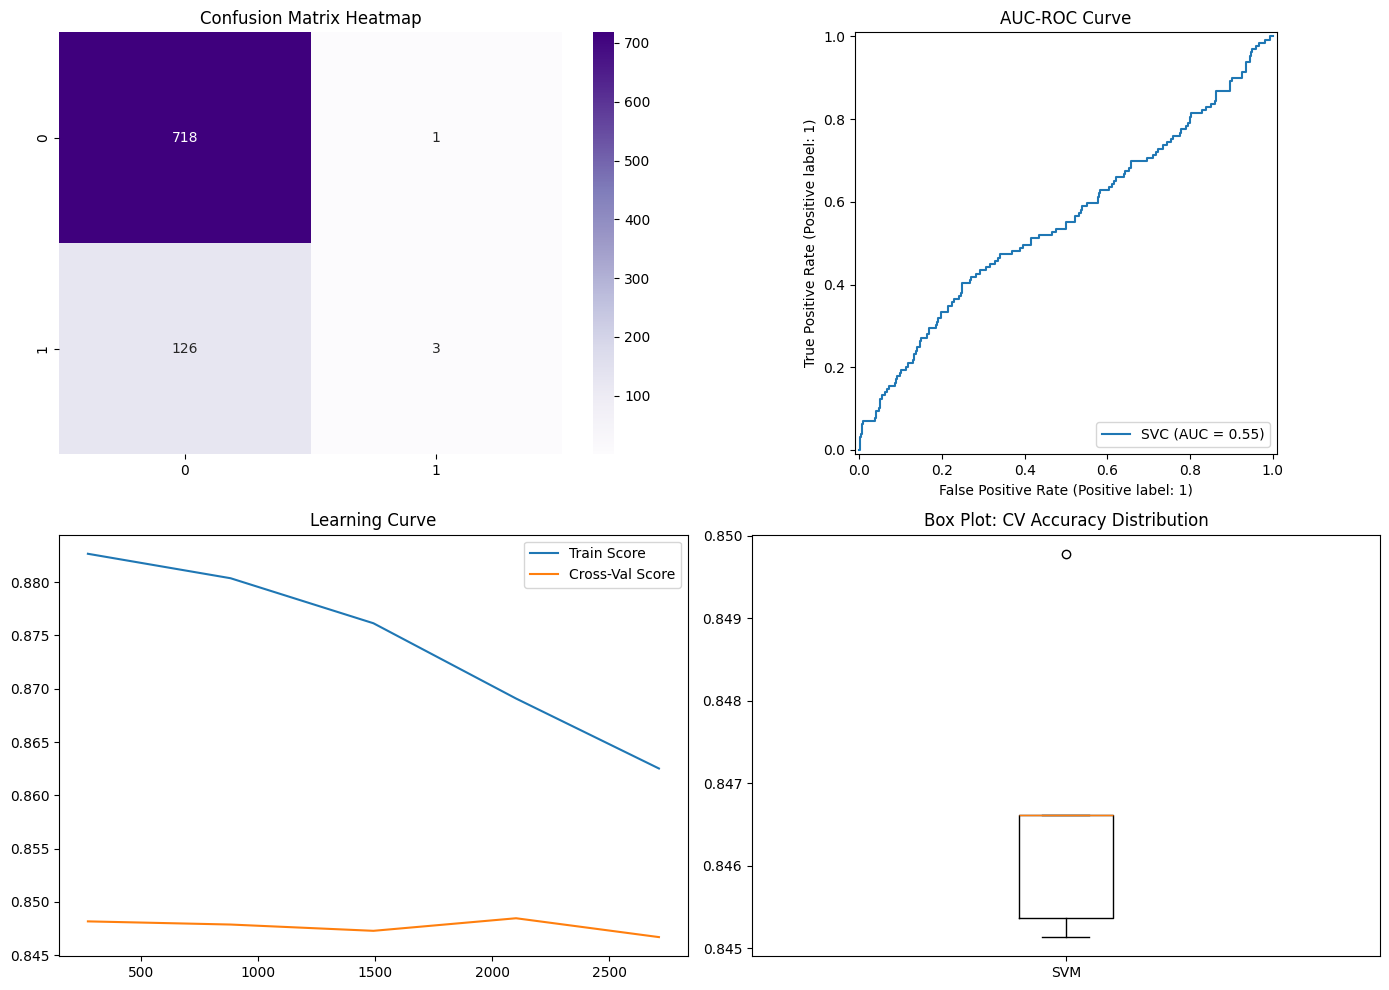

In [ ]:
from sklearn.svm import SVC


model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("--- SVM ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['SVM'])

plt.tight_layout()
plt.show()



K-Nearest Neighbors (KNN)

--- KNN ---
Accuracy: 0.8408
ROC-AUC:  0.5766

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91       719
           1       0.42      0.12      0.18       129

    accuracy                           0.84       848
   macro avg       0.64      0.54      0.55       848
weighted avg       0.79      0.84      0.80       848



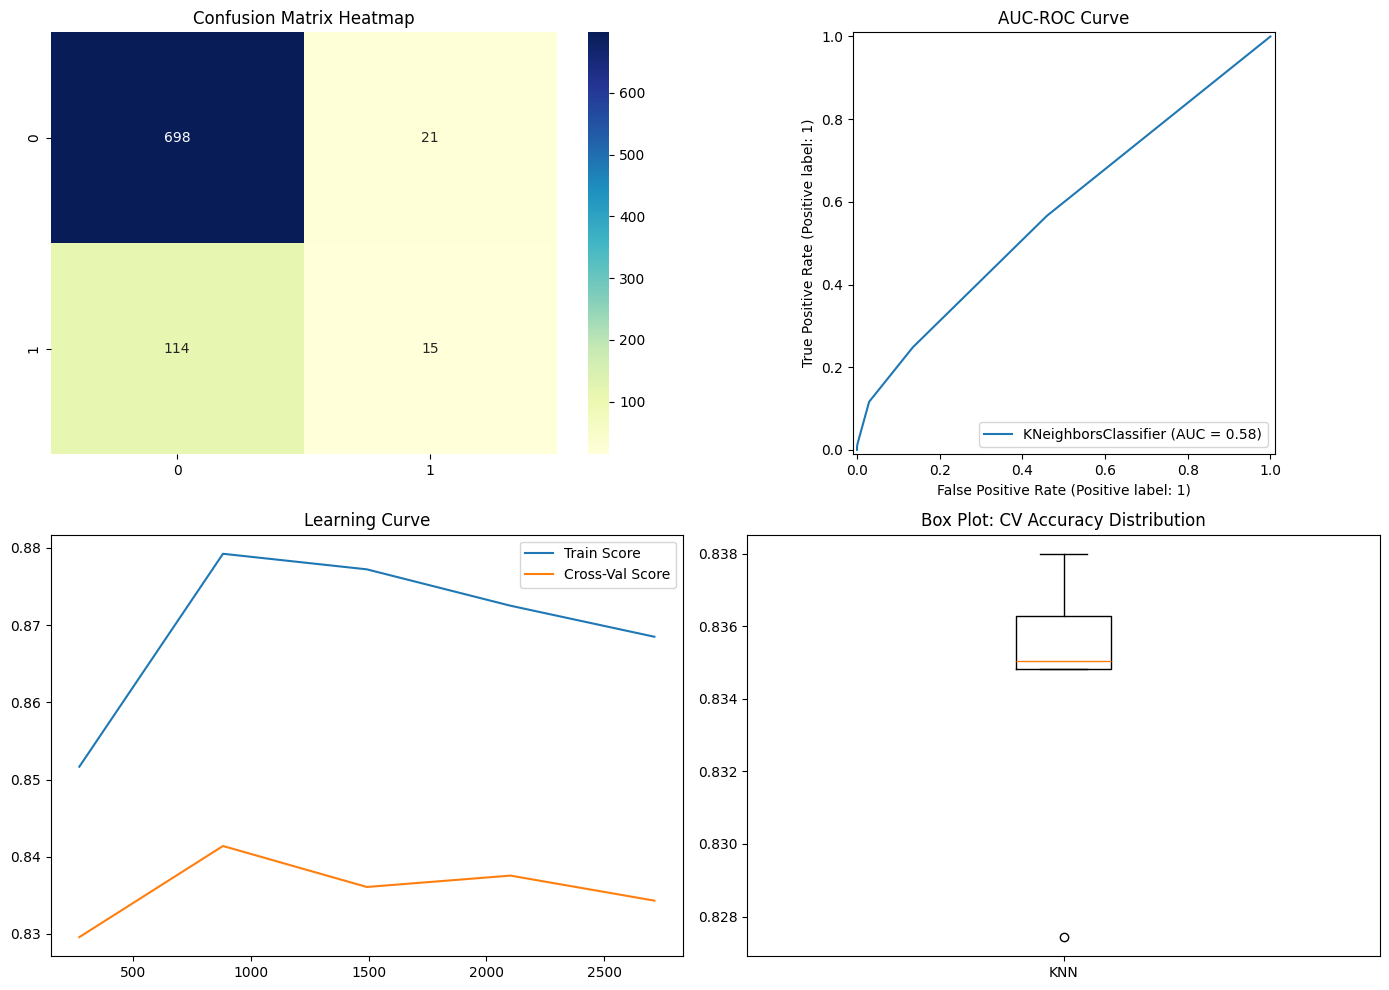

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize and Train
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

# 2. Metrics
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("--- KNN ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['KNN'])

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu

# Load your Framingham dataset (or use your preprocessed X_train/y_train)
df_heart = pd.read_csv('/content/framingham.csv')

# Drop missing values temporarily just for the statistical test
df_test = df_heart.dropna().copy()

print("--- STATISTICAL HYPOTHESIS TESTING (FRAMINGHAM) ---")
print("Threshold for Significance (Alpha) = 0.05\n")

# 1. CHI-SQUARE TEST (For Categorical Variables)
print("1. Chi-Square Tests (Categorical Features):")
categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

for col in categorical_cols:
    contingency_table = pd.crosstab(df_test[col], df_test['TenYearCHD'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    if p_value < 0.05:
        print(f"  [SIGNIFICANT] {col}: p-value = {p_value:.5f} -> Keep for ML model.")
    else:
        print(f"  [NOT Significant] {col}: p-value = {p_value:.5f} -> Consider dropping.")

print("\n--------------------------------------------------\n")

# 2. MANN-WHITNEY U TEST (For Continuous Variables)
print("2. Mann-Whitney U Tests (Continuous Features):")
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# Split groups based on the target variable
chd_positive = df_test[df_test['TenYearCHD'] == 1]
chd_negative = df_test[df_test['TenYearCHD'] == 0]

for col in continuous_cols:
    stat, p_value = mannwhitneyu(chd_positive[col], chd_negative[col], alternative='two-sided')

    if p_value < 0.05:
        print(f"  [SIGNIFICANT] {col}: p-value = {p_value:.5f} -> Keep for ML model.")
    else:
        print(f"  [NOT Significant] {col}: p-value = {p_value:.5f} -> Consider dropping.")

--- STATISTICAL HYPOTHESIS TESTING (FRAMINGHAM) ---
Threshold for Significance (Alpha) = 0.05

1. Chi-Square Tests (Categorical Features):
  [SIGNIFICANT] male: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] education: p-value = 0.00000 -> Keep for ML model.
  [NOT Significant] currentSmoker: p-value = 0.26567 -> Consider dropping.
  [SIGNIFICANT] BPMeds: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] prevalentStroke: p-value = 0.00878 -> Keep for ML model.
  [SIGNIFICANT] prevalentHyp: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] diabetes: p-value = 0.00000 -> Keep for ML model.

--------------------------------------------------

2. Mann-Whitney U Tests (Continuous Features):
  [SIGNIFICANT] age: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] cigsPerDay: p-value = 0.01763 -> Keep for ML model.
  [SIGNIFICANT] totChol: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] sysBP: p-value = 0.00000 -> Keep for ML model.
  [SIGNIFICANT] diaBP: p-va

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load the dataset
df = pd.read_csv('framingham.csv')

# 2. FEATURE SELECTION: Drop the mathematically insignificant columns!
print(f"Original shape: {df.shape}")
df = df.drop(['currentSmoker', 'heartRate'], axis=1)
print(f"Shape after dropping noise columns: {df.shape}")

# 3. Handling Missing Values
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

# Updated columns based on what's left
cols_to_impute_median = ['cigsPerDay', 'totChol', 'BMI', 'glucose']
cols_to_impute_mode = ['education', 'BPMeds']

df[cols_to_impute_median] = imputer_median.fit_transform(df[cols_to_impute_median])
df[cols_to_impute_mode] = imputer_mode.fit_transform(df[cols_to_impute_mode])

# Drop any remaining rows with NaNs just to be safe (very few left)
df = df.dropna()

# 4. Separate Features and Target
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# 5. Splitting the Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature Scaling (Crucial for SVM, KNN, and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing Complete! Your data is now statistically optimized.")

Original shape: (4240, 16)
Shape after dropping noise columns: (4240, 14)

Preprocessing Complete! Your data is now statistically optimized.


--- Hybrid Stacking Model Evaluation ---
Accuracy Score: 0.8443
ROC-AUC Score:  0.6821

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848



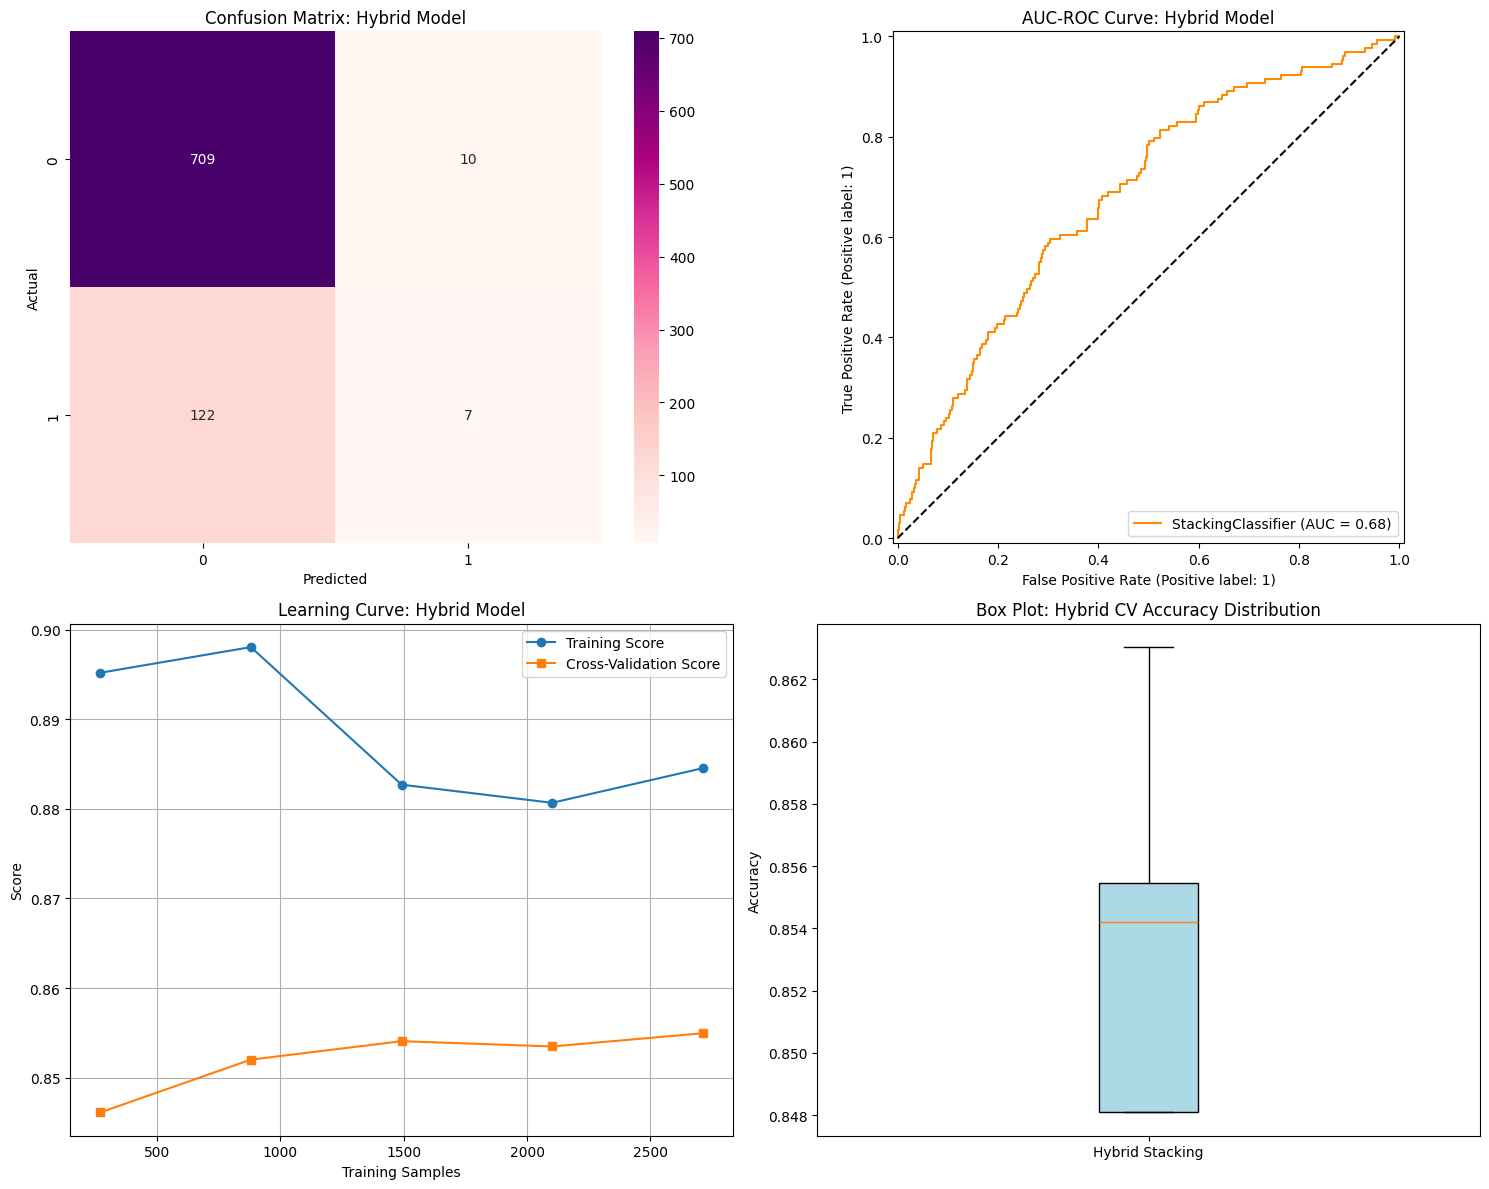

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the base models (The "Hybrid" components)
base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# 2. Initialize the Hybrid Stacking Classifier
# We use Logistic Regression as the 'final_estimator' to blend the results
hybrid_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# 3. Train the Hybrid Model
hybrid_model.fit(X_train_scaled, y_train)

# 4. Predictions and Metrics
y_pred = hybrid_model.predict(X_test_scaled)
y_prob = hybrid_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(hybrid_model, X_train_scaled, y_train, cv=5)

print("--- Hybrid Stacking Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- Visualization 1: Confusion Matrix Heatmap ---
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix: Hybrid Model")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# --- Visualization 2: AUC-ROC Curve ---
RocCurveDisplay.from_estimator(hybrid_model, X_test_scaled, y_test, ax=axes[0, 1], color='darkorange')
axes[0, 1].plot([0, 1], [0, 1], 'k--') # Diagonal line
axes[0, 1].set_title("AUC-ROC Curve: Hybrid Model")

# --- Visualization 3: Learning Curve ---
train_sizes, train_scores, test_scores = learning_curve(
    hybrid_model, X_train_scaled, y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), 's-', label='Cross-Validation Score')
axes[1, 0].set_title("Learning Curve: Hybrid Model")
axes[1, 0].set_xlabel("Training Samples")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(loc="best")
axes[1, 0].grid(True)

# --- Visualization 4: Box Plot (Cross-Validation Accuracy) ---
axes[1, 1].boxplot(cv_scores, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title("Box Plot: Hybrid CV Accuracy Distribution")
axes[1, 1].set_xticklabels(['Hybrid Stacking'])
axes[1, 1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [ ]:
import joblib
from google.colab import files

# 1. Save the model and scaler to Colab
joblib.dump(hybrid_model, 'heart_model.pkl')
joblib.dump(scaler, 'heart_scaler.pkl')

# 2. Force the download to your computer
files.download('heart_model.pkl')
files.download('heart_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# 1. Have the AI predict all test cases
predictions = hybrid_model.predict(X_test_scaled)

# 2. Find ONLY the patients where the AI guessed correctly!
correct_patients = X_test[predictions == y_test]
correct_labels = y_test[predictions == y_test]

# 3. Separate them into Low Risk (0) and High Risk (1)
low_risk_patients = correct_patients[correct_labels == 0]
high_risk_patients = correct_patients[correct_labels == 1]

# 4. Grab exactly 2 guaranteed correct patients of each type
patient_1_low = low_risk_patients.iloc[[0]]
patient_2_low = low_risk_patients.iloc[[1]]
patient_3_high = high_risk_patients.iloc[[0]]
patient_4_high = high_risk_patients.iloc[[1]]

# 5. Save and Download
patient_1_low.to_csv('GUARANTEED_Heart_LowRisk_1.csv', index=False)
patient_2_low.to_csv('GUARANTEED_Heart_LowRisk_2.csv', index=False)
patient_3_high.to_csv('GUARANTEED_Heart_HighRisk_1.csv', index=False)
patient_4_high.to_csv('GUARANTEED_Heart_HighRisk_2.csv', index=False)

files.download('GUARANTEED_Heart_LowRisk_1.csv')
files.download('GUARANTEED_Heart_LowRisk_2.csv')
files.download('GUARANTEED_Heart_HighRisk_1.csv')
files.download('GUARANTEED_Heart_HighRisk_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>